### imports and data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy.table import Table, vstack,hstack
import numpy.ma as ma
# import marvin
import pyneb as pn
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
from elliptical_plottingFunctions import *
from IO_data import *
from elliptical_stellar_mass import calc_mass_curve
from elliptical_stellar_mass_functions import exponential_disk, exponential_sphere, exponential_sphere_disk
from matplotlib.lines import Line2D

from scipy.optimize import curve_fit

In [2]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_v6.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,Mvir2,Mvir2_err,star_sigma2,star_sigma2_err,e_Mstar_R90,BPT_class,sum_M_star_0p1_R90,count_M_star_0p1_R90
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float

In [3]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [4]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [5]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/paper_plots/final/gaussian_fits/'

In [6]:
ellipticals = master_table[master_table['Mvir'] > 0]
ellipticals = ellipticals[ellipticals['sphd_M_star'] > 0]
spirals = master_table[master_table['v_max'] > 0]
spirals = spirals[spirals['M90_disk'] > 0]
spirals = spirals[spirals['alpha'] <= 99]
spirals = spirals[spirals['v_max_err']/spirals['v_max'] <= 2]
v90 = spirals['v_max'] * spirals['R90_kpc'] / (spirals['r_turn']**spirals['alpha'] + spirals['R90_kpc']**spirals['alpha'])**(1/spirals['alpha'])
all_mass_spirals = spirals[np.logical_and(v90 > 10, v90 < 1000)]
spirals = all_mass_spirals[all_mass_spirals['M90_disk']>9]

In [7]:
nsa_portsmouth = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/NSA_v1_0_1_vflag_Portsmouth.fits')
nsa_portsmouth[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

In [8]:
nsa_dict = {}
for i in range(len(nsa_portsmouth)):
    nsa_dict[nsa_portsmouth['NSAID'][i]] = i

In [9]:
p3d = Table.read(DATA_FOLDER + 'SDSS17Pipe3D_v3_1_1.fits', format='fits')
p3d[:5]

name,plate,ifudsgn,plateifu,mangaid,objra,objdec,log_SFR_Ha,FoV,Re_kpc,e_log_Mass,e_log_SFR_Ha,log_Mass,log_SFR_ssp,log_NII_Ha_cen,e_log_NII_Ha_cen,log_OIII_Hb_cen,e_log_OIII_Hb_cen,log_SII_Ha_cen,e_log_SII_Ha_cen,log_OII_Hb_cen,e_log_OII_Hb_cen,EW_Ha_cen,e_EW_Ha_cen,ZH_LW_Re_fit,e_ZH_LW_Re_fit,alpha_ZH_LW_Re_fit,e_alpha_ZH_LW_Re_fit,ZH_MW_Re_fit,e_ZH_MW_Re_fit,alpha_ZH_MW_Re_fit,e_alpha_ZH_MW_Re_fit,Age_LW_Re_fit,e_Age_LW_Re_fit,alpha_Age_LW_Re_fit,e_alpha_Age_LW_Re_fit,Age_MW_Re_fit,e_Age_MW_Re_fit,alpha_Age_MW_Re_fit,e_alpha_Age_MW_Re_fit,Re_arc,DL,DA,PA,ellip,log_Mass_gas,vel_sigma_Re,e_vel_sigma_Re,log_SFR_SF,log_SFR_D_C,OH_O3N2_cen,e_OH_O3N2_cen,OH_N2_cen,e_OH_N2_cen,OH_ONS_cen,e_OH_ONS_cen,OH_R23_cen,e_OH_R23_cen,OH_pyqz_cen,e_OH_pyqz_cen,OH_t2_cen,e_OH_t2_cen,OH_M08_cen,e_OH_M08_cen,OH_T04_cen,e_OH_T04_cen,OH_dop_cen,e_OH_dop_cen,OH_O3N2_EPM09_cen,e_OH_O3N2_EPM09_cen,log_OI_Ha_cen,e_log_OI_Ha_cen,Ha_Hb_cen,e_Ha_Hb_cen,log_NII_Ha_Re,e_log_NII_Ha_Re,log_OIII_Hb_Re,e_log_OIII_Hb_Re,log_SII_Ha_Re,e_log_SII_Ha_Re,log_OII_Hb_Re,e_log_OII_Hb_Re,log_OI_Ha_Re,e_log_OI_Ha_Re,EW_Ha_Re,e_EW_Ha_Re,Ha_Hb_Re,e_Ha_Hb_Re,log_NII_Ha_ALL,e_log_NII_Ha_ALL,log_OIII_Hb_ALL,e_log_OIII_Hb_ALL,log_SII_Ha_ALL,e_log_SII_Ha_ALL,log_OII_Hb_ALL,e_log_OII_Hb_ALL,log_OI_Ha_ALL,e_log_OI_Ha_ALL,EW_Ha_ALL,e_EW_Ha_ALL,Ha_Hb_ALL,Sigma_Mass_cen,e_Sigma_Mass_cen,Sigma_Mass_Re,e_Sigma_Mass_Re,Sigma_Mass_ALL,e_Sigma_Mass_ALL,T30,ZH_T30,ZH_Re_T30,a_ZH_T30,T40,ZH_T40,ZH_Re_T40,a_ZH_T40,T50,ZH_T50,ZH_Re_T50,a_ZH_T50,T60,ZH_T60,ZH_Re_T60,a_ZH_T60,T70,ZH_T70,ZH_Re_T70,a_ZH_T70,T80,ZH_T80,ZH_Re_T80,a_ZH_T80,T90,ZH_T90,ZH_Re_T90,a_ZH_T90,T95,ZH_T95,ZH_Re_T95,a_ZH_T95,T99,ZH_T99,ZH_Re_T99,a_ZH_T99,log_Mass_gas_Av_gas_OH,log_Mass_gas_Av_ssp_OH,vel_ssp_2,e_vel_ssp_2,vel_Ha_2,e_vel_Ha_2,vel_ssp_1,e_vel_ssp_1,vel_Ha_1,e_vel_Ha_1,log_SFR_ssp_100Myr,log_SFR_ssp_10Myr,vel_disp_Ha_cen,vel_disp_ssp_cen,vel_disp_Ha_1Re,vel_disp_ssp_1Re,log_Mass_in_Re,ML_int,ML_avg,F_Ha_cen,e_F_Ha_cen,R50_kpc_V,e_R50_kpc_V,R50_kpc_Mass,e_R50_kpc_Mass,log_Mass_corr_in_R50_V,e_log_Mass_corr_in_R50_V,log_Mass_gas_Av_gas_log_log,Av_gas_Re,e_Av_gas_Re,Av_ssp_Re,e_Av_ssp_Re,Lambda_Re,e_Lambda_Re,nsa_redshift,nsa_mstar,nsa_inclination,flux_[OII]3726.03_Re_fit,e_flux_[OII]3726.03_Re_fit,flux_[OII]3726.03_alpha_fit,e_flux_[OII]3726.03_alpha_fit,flux_[OII]3728.82_Re_fit,e_flux_[OII]3728.82_Re_fit,flux_[OII]3728.82_alpha_fit,e_flux_[OII]3728.82_alpha_fit,flux_HI3734.37_Re_fit,e_flux_HI3734.37_Re_fit,flux_HI3734.37_alpha_fit,e_flux_HI3734.37_alpha_fit,flux_HI3797.9_Re_fit,e_flux_HI3797.9_Re_fit,flux_HI3797.9_alpha_fit,e_flux_HI3797.9_alpha_fit,flux_HeI3888.65_Re_fit,e_flux_HeI3888.65_Re_fit,flux_HeI3888.65_alpha_fit,e_flux_HeI3888.65_alpha_fit,flux_HI3889.05_Re_fit,e_flux_HI3889.05_Re_fit,flux_HI3889.05_alpha_fit,e_flux_HI3889.05_alpha_fit,flux_HeI3964.73_Re_fit,e_flux_HeI3964.73_Re_fit,flux_HeI3964.73_alpha_fit,e_flux_HeI3964.73_alpha_fit,flux_[NeIII]3967.46_Re_fit,e_flux_[NeIII]3967.46_Re_fit,flux_[NeIII]3967.46_alpha_fit,e_flux_[NeIII]3967.46_alpha_fit,flux_CaII3968.47_Re_fit,e_flux_CaII3968.47_Re_fit,flux_CaII3968.47_alpha_fit,e_flux_CaII3968.47_alpha_fit,flux_Hepsilon3970.07_Re_fit,e_flux_Hepsilon3970.07_Re_fit,flux_Hepsilon3970.07_alpha_fit,e_flux_Hepsilon3970.07_alpha_fit,flux_Hdelta4101.77_Re_fit,e_flux_Hdelta4101.77_Re_fit,flux_Hdelta4101.77_alpha_fit,e_flux_Hdelta4101.77_alpha_fit,flux_Hgamma4340.49_Re_fit,e_flux_Hgamma4340.49_Re_fit,flux_Hgamma4340.49_alpha_fit,e_flux_Hgamma4340.49_alpha_fit,flux_Hbeta4861.36_Re_fit,e_flux_Hbeta4861.36_Re_fit,flux_Hbeta4861.36_alpha_fit,e_flux_Hbeta4861.36_alpha_fit,flux_[OIII]4958.91_Re_fit,e_flux_[OIII]4958.91_Re_fit,flux_[OIII]4958.91_alpha_fit,e_flux_[OIII]4958.91_alpha_fit,flux_[OIII]5006.84_Re_fit,e_flux_[OIII]5006.84_Re_fit,flux_[OIII]5006.84_alpha_fit,e_flux_[OIII]5006.84_alpha_fit,flux_HeI5015.68_Re_fit,e_flux_HeI5015.68_Re_fit,flux_HeI5015.68_alpha_fit,e_flux_HeI5015.68_alpha_fit,flux_[NI]5197.9_Re_fit,e_flux_[NI]5197.9_Re_fit,flux_[NI]5197.9_alpha_fit

In [10]:
p3d_dict = {}
for i in range(len(p3d)):
    p3d_dict[p3d[i]['plateifu']] = i

In [11]:
ellipticals['Age_LW_Re_fit'] = -99.
ellipticals['Age_MW_Re_fit'] = -99.
ellipticals['ZH_LW_Re_fit'] = -99.
ellipticals['ZH_MW_Re_fit'] = -99.

for i in range(len(ellipticals)):

    try:

        i_p = p3d_dict[ellipticals[i]['plateifu']]

        ellipticals['Age_LW_Re_fit'][i] = p3d[i_p]['Age_LW_Re_fit']
        ellipticals['Age_MW_Re_fit'][i] = p3d[i_p]['Age_MW_Re_fit']
        ellipticals['ZH_LW_Re_fit'][i] = p3d[i_p]['ZH_LW_Re_fit']
        ellipticals['ZH_MW_Re_fit'][i] = p3d[i_p]['ZH_MW_Re_fit']
    
    except:
        print(ellipticals[i]['plateifu'])

10496-3704
10837-12702
11980-3703
12678-3702
12683-1902
9514-6102


/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/astropy/table/column.py:1376: UserWarning: Warning: converting a masked element to nan.
  self.data[index] = value


In [12]:
G = 4.3009 * 10**-6 # [kpc (km/s)^2 / M_sun]
H_0 = 100 # [km / s / Mpc]
c = 299792.458 # Speed of light in units of km/s

In [13]:
blue_spirals = spirals[spirals['CMD_class'] == 1]
green_spirals = spirals[spirals['CMD_class']==2]
red_spirals = spirals[spirals['CMD_class']==3]

In [14]:
def lin_fit(x, a, b):

    return a*x + b

### mstar & mtot vs mr within r90 by cmd

In [15]:
#define bins

mr_bins =  np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)


#### ellipticals

In [16]:
# ellipticals
e_mr_ctrs = []
e_mstar = []
e_mtot = []
e_mr_bins = np.concatenate((mr_bins[0:11], mr_bins[-1:]))

for i in range(len(e_mr_bins)-1):
    
    mag_lim = e_mr_bins[i+1]
    
    if i == 0:
        e_mstar.append(ellipticals['e_Mstar_R90'][ellipticals['rabsmag'] <= mag_lim]+np.log10(0.73))
        e_mtot.append(ellipticals['Mvir'][ellipticals['rabsmag'] <= mag_lim])
        e_mr_ctrs.append(np.mean(ellipticals['rabsmag'][ellipticals['rabsmag'] <= mag_lim]+np.log10(0.73)))

    else:
        lower_lim = e_mr_bins[i]
        e_mstar.append(ellipticals['e_Mstar_R90'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)]+np.log10(0.73))
        e_mtot.append(ellipticals['Mvir'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)])
        e_mr_ctrs.append(np.mean(ellipticals['rabsmag'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)]+np.log10(0.73)))

e_mstar_avg, e_mstar_sig = fit_to_gaussian(e_mstar, plot_dir = plot_dir, plot_name='ellipticals_Mstar90_Mr', xlab=r'$M_*$')
e_mtot_avg, e_mtot_sig = fit_to_gaussian(e_mtot, plot_dir = plot_dir, plot_name='ellipticals_Mtot_Mr', xlab=r'$M_{\rm tot}$')

# fit da lines

e_mstar_popt, e_mstar_pcov = curve_fit(lin_fit, e_mr_ctrs, 
                                       e_mstar_avg, sigma=e_mstar_sig)
e_mtot_popt, e_mtot_pcov = curve_fit(lin_fit, e_mr_ctrs, 
                                       e_mtot_avg, sigma=e_mtot_sig)

print(e_mstar_popt, np.sqrt(e_mstar_pcov[0,0]), np.sqrt(e_mstar_pcov[1,1]))
print(e_mtot_popt, np.sqrt(e_mtot_pcov[0,0]), np.sqrt(e_mtot_pcov[1,1]))

[-0.39384922  2.61270912] 0.005497515250715805 0.11756940560931477
[-0.5010032   0.67728308] 0.010501245929655926 0.22494587764505228


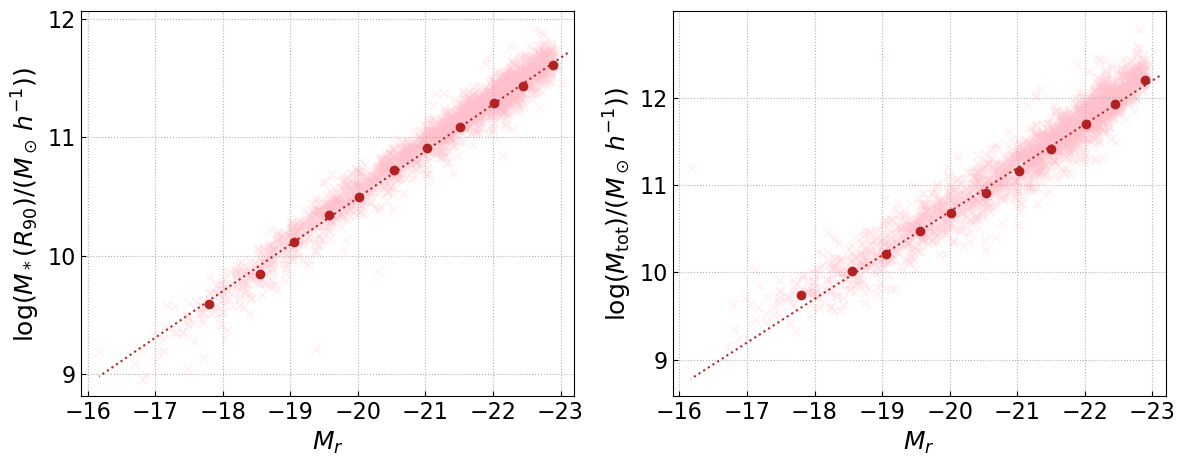

In [17]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].scatter(ellipticals['rabsmag'], ellipticals['e_Mstar_R90']+np.log10(0.73), marker='x', color='pink', alpha=0.2)
ax[1].scatter(ellipticals['rabsmag'], ellipticals['Mvir'], marker='x', color='pink', alpha=0.2)
ax[0].errorbar(e_mr_ctrs, e_mstar_avg, yerr=e_mstar_sig, color='firebrick', linestyle='none', marker='o')
ax[1].errorbar(e_mr_ctrs, e_mtot_avg, yerr=e_mtot_sig, color='firebrick', linestyle='none', marker='o')
ax[0].set_yticks(np.arange(9,13,1))
ax[1].set_yticks(np.arange(9,14,1))
ax[0].set_ylabel(r'$\log(M_*(R_{90})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[1].set_ylabel(r'$\log(M_{\rm tot})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[0].plot(e_mr_bins, e_mr_bins*e_mstar_popt[0] + e_mstar_popt[1], linestyle=':', color='firebrick')
ax[1].plot(e_mr_bins, e_mr_bins*e_mtot_popt[0] + e_mtot_popt[1], linestyle=':', color='firebrick')


for i in range(2):
    ax[i].set_xlim(-15.9,-23.2)
    ax[i].set_xlabel(r'$M_r$', fontsize=18)
    ax[i].tick_params( axis='both', direction='in', labelsize=16)
    ax[i].grid( linestyle=':')
    ax[i].set_xticks(np.arange(-23,-15,1))


fig.subplots_adjust(wspace=0.2, hspace=0.05)


#### blue spirals

In [18]:
bs_mr_ctrs = []
bs_mstar = []
bs_mtot = []
bs_mr_bins = np.concatenate((mr_bins[:0], mr_bins[2:-3], mr_bins[-1:]))

for i in range(len(bs_mr_bins)-1):
    
    mag_lim = bs_mr_bins[i+1]
    
    if i == 0:
        bs_mstar.append(blue_spirals['M90_disk'][blue_spirals['rabsmag'] <= mag_lim]+np.log10(0.73))
        bs_mtot.append(blue_spirals['M_R90'][blue_spirals['rabsmag'] <= mag_lim])
        bs_mr_ctrs.append(np.mean(blue_spirals['rabsmag'][blue_spirals['rabsmag'] <= mag_lim]+np.log10(0.73)))

    else:
        lower_lim = bs_mr_bins[i]
        bs_mstar.append(blue_spirals['M90_disk'][np.logical_and(blue_spirals['rabsmag'] <= mag_lim, 
                                                                         blue_spirals['rabsmag'] > lower_lim)]+np.log10(0.73))
        bs_mtot.append(blue_spirals['M_R90'][np.logical_and(blue_spirals['rabsmag'] <= mag_lim, 
                                                                         blue_spirals['rabsmag'] > lower_lim)])
        bs_mr_ctrs.append(np.mean(blue_spirals['rabsmag'][np.logical_and(blue_spirals['rabsmag'] <= mag_lim, 
                                                                         blue_spirals['rabsmag'] > lower_lim)]+np.log10(0.73)))

bs_mstar_avg, bs_mstar_sig = fit_to_gaussian(bs_mstar, plot_dir = plot_dir, plot_name='bs_Mstar90_Mr', xlab=r'$M_*$')
bs_mtot_avg, bs_mtot_sig = fit_to_gaussian(bs_mtot, plot_dir = plot_dir, plot_name='bs_Mtot_Mr', xlab=r'$M_{\rm tot}$')

# fit da lines

bs_mstar_popt, bs_mstar_pcov = curve_fit(lin_fit, bs_mr_ctrs, 
                                       bs_mstar_avg, sigma=bs_mstar_sig)
bs_mtot_popt, bs_mtot_pcov = curve_fit(lin_fit, bs_mr_ctrs, 
                                       bs_mtot_avg, sigma=bs_mtot_sig)

print(bs_mstar_popt, np.sqrt(bs_mstar_pcov[0,0]), np.sqrt(bs_mstar_pcov[1,1]))
print(bs_mtot_popt, np.sqrt(bs_mtot_pcov[0,0]), np.sqrt(bs_mtot_pcov[1,1]))

[-0.44659971  1.26251163] 0.005279835010931354 0.10462711341224294
[-0.3594647   3.57174394] 0.009673654186529051 0.19212217833560477


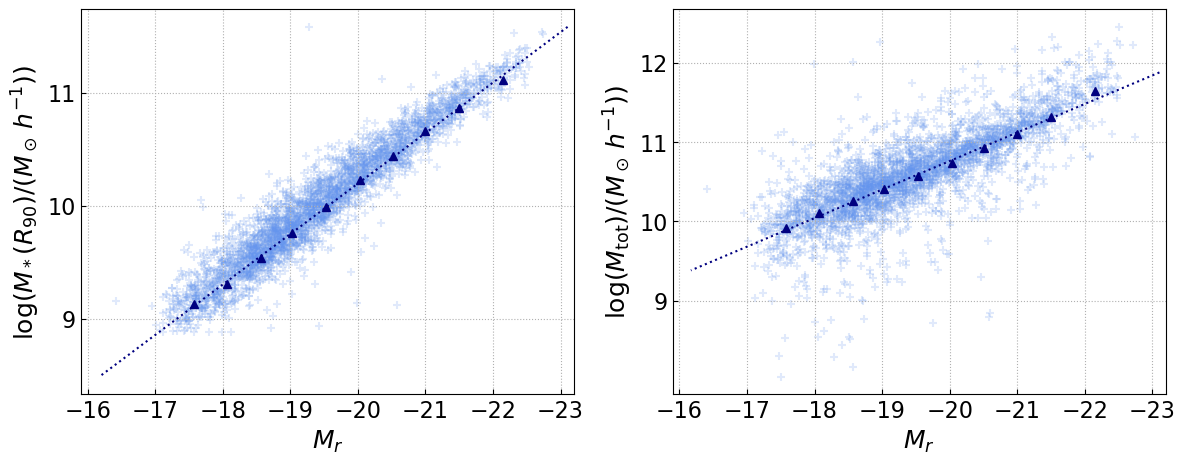

In [19]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].scatter(blue_spirals['rabsmag'], blue_spirals['M90_disk']+np.log10(0.73), marker='+', color='cornflowerblue', alpha=0.2)
ax[1].scatter(blue_spirals['rabsmag'], blue_spirals['M_R90'], marker='+', color='cornflowerblue', alpha=0.2)
ax[0].errorbar(bs_mr_ctrs, bs_mstar_avg, yerr=bs_mstar_sig, color='navy', linestyle='none', marker='^')
ax[1].errorbar(bs_mr_ctrs, bs_mtot_avg, yerr=bs_mtot_sig, color='navy', linestyle='none', marker='^')
ax[0].set_yticks(np.arange(9,13,1))
ax[1].set_yticks(np.arange(9,14,1))
ax[0].set_ylabel(r'$\log(M_*(R_{90})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[1].set_ylabel(r'$\log(M_{\rm tot})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[0].plot(mr_bins, mr_bins*bs_mstar_popt[0] + bs_mstar_popt[1], linestyle=':', color='navy')
ax[1].plot(mr_bins, mr_bins*bs_mtot_popt[0] + bs_mtot_popt[1], linestyle=':', color='navy')


for i in range(2):
    ax[i].set_xlim(-15.9,-23.2)
    ax[i].set_xlabel(r'$M_r$', fontsize=18)
    ax[i].tick_params( axis='both', direction='in', labelsize=16)
    ax[i].grid( linestyle=':')
    ax[i].set_xticks(np.arange(-23,-15,1))


fig.subplots_adjust(wspace=0.2, hspace=0.05)


#### green spirals

In [20]:
gs_mr_ctrs = []
gs_mstar = []
gs_mtot = []
gs_mr_bins = np.concatenate((mr_bins[:0], mr_bins[2:10], mr_bins[-1:]))

for i in range(len(gs_mr_bins)-1):
    
    mag_lim = gs_mr_bins[i+1]
    
    if i == 0:
        gs_mstar.append(green_spirals['M90_disk'][green_spirals['rabsmag'] <= mag_lim]+np.log10(0.73))
        gs_mtot.append(green_spirals['M_R90'][green_spirals['rabsmag'] <= mag_lim])
        gs_mr_ctrs.append(np.mean(green_spirals['rabsmag'][green_spirals['rabsmag'] <= mag_lim]+np.log10(0.73)))

    else:
        lower_lim = gs_mr_bins[i]
        gs_mstar.append(green_spirals['M90_disk'][np.logical_and(green_spirals['rabsmag'] <= mag_lim, 
                                                                         green_spirals['rabsmag'] > lower_lim)]+np.log10(0.73))
        gs_mtot.append(green_spirals['M_R90'][np.logical_and(green_spirals['rabsmag'] <= mag_lim, 
                                                                         green_spirals['rabsmag'] > lower_lim)])
        gs_mr_ctrs.append(np.mean(green_spirals['rabsmag'][np.logical_and(green_spirals['rabsmag'] <= mag_lim, 
                                                                         green_spirals['rabsmag'] > lower_lim)]+np.log10(0.73)))

gs_mstar_avg, gs_mstar_sig = fit_to_gaussian(gs_mstar, plot_dir = plot_dir, plot_name='gs_Mstar90_Mr', xlab=r'$M_*$')
gs_mtot_avg, gs_mtot_sig = fit_to_gaussian(gs_mtot, plot_dir = plot_dir, plot_name='gs_Mtot_Mr', xlab=r'$M_{\rm tot}$')

# fit da lines

gs_mstar_popt, gs_mstar_pcov = curve_fit(lin_fit, gs_mr_ctrs, 
                                       gs_mstar_avg, sigma=gs_mstar_sig)
gs_mtot_popt, gs_mtot_pcov = curve_fit(lin_fit, gs_mr_ctrs, 
                                       gs_mtot_avg, sigma=gs_mtot_sig)

print(gs_mstar_popt, np.sqrt(gs_mstar_pcov[0,0]), np.sqrt(gs_mstar_pcov[1,1]))
print(gs_mtot_popt, np.sqrt(gs_mtot_pcov[0,0]), np.sqrt(gs_mtot_pcov[1,1]))

[-0.41804525  1.99218286] 0.01341367950604396 0.2770960322938272
[-0.39813455  2.86649232] 0.008180697026924278 0.16789240767851135


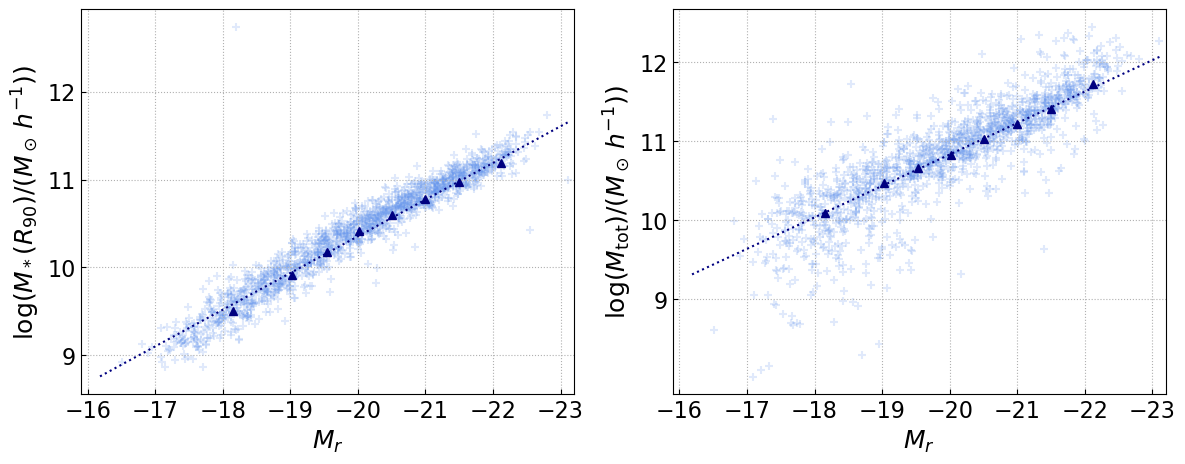

In [21]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].scatter(green_spirals['rabsmag'], green_spirals['M90_disk']+np.log10(0.73), marker='+', color='cornflowerblue', alpha=0.2)
ax[1].scatter(green_spirals['rabsmag'], green_spirals['M_R90'], marker='+', color='cornflowerblue', alpha=0.2)
ax[0].errorbar(gs_mr_ctrs, gs_mstar_avg, yerr=gs_mstar_sig, color='navy', linestyle='none', marker='^')
ax[1].errorbar(gs_mr_ctrs, gs_mtot_avg, yerr=gs_mtot_sig, color='navy', linestyle='none', marker='^')
ax[0].set_yticks(np.arange(9,13,1))
ax[1].set_yticks(np.arange(9,14,1))
ax[0].set_ylabel(r'$\log(M_*(R_{90})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[1].set_ylabel(r'$\log(M_{\rm tot})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[0].plot(mr_bins, mr_bins*gs_mstar_popt[0] + gs_mstar_popt[1], linestyle=':', color='navy')
ax[1].plot(mr_bins, mr_bins*gs_mtot_popt[0] + gs_mtot_popt[1], linestyle=':', color='navy')


for i in range(2):
    ax[i].set_xlim(-15.9,-23.2)
    ax[i].set_xlabel(r'$M_r$', fontsize=18)
    ax[i].tick_params( axis='both', direction='in', labelsize=16)
    ax[i].grid( linestyle=':')
    ax[i].set_xticks(np.arange(-23,-15,1))


fig.subplots_adjust(wspace=0.2, hspace=0.05)


#### red spiral

In [22]:
rs_mr_ctrs = []
rs_mstar = []
rs_mtot = []
rs_mr_bins = np.concatenate((mr_bins[:0], mr_bins[2:-7], mr_bins[-1:]))
# rs_mr_bins = mr_bins[0:-1:3]
# rs_mr_bins = mr_bins

for i in range(len(rs_mr_bins)-1):
    
    mag_lim = rs_mr_bins[i+1]
    
    if i == 0:
        rs_mstar.append(red_spirals['M90_disk'][red_spirals['rabsmag'] <= mag_lim]+np.log10(0.73))
        rs_mtot.append(red_spirals['M_R90'][red_spirals['rabsmag'] <= mag_lim])
        rs_mr_ctrs.append(np.mean(red_spirals['rabsmag'][red_spirals['rabsmag'] <= mag_lim]+np.log10(0.73)))

    else:
        lower_lim = rs_mr_bins[i]
        rs_mstar.append(red_spirals['M90_disk'][np.logical_and(red_spirals['rabsmag'] <= mag_lim, 
                                                                         red_spirals['rabsmag'] > lower_lim)]+np.log10(0.73))
        rs_mtot.append(red_spirals['M_R90'][np.logical_and(red_spirals['rabsmag'] <= mag_lim, 
                                                                         red_spirals['rabsmag'] > lower_lim)])
        rs_mr_ctrs.append(np.mean(red_spirals['rabsmag'][np.logical_and(red_spirals['rabsmag'] <= mag_lim, 
                                                                         red_spirals['rabsmag'] > lower_lim)]+np.log10(0.73)))

rs_mstar_avg, rs_mstar_sig = fit_to_gaussian(rs_mstar, plot_dir = plot_dir, plot_name='rs_Mstar90_Mr', xlab=r'$M_*$')
rs_mtot_avg, rs_mtot_sig = fit_to_gaussian(rs_mtot, plot_dir = plot_dir, plot_name='rs_Mtot_Mr', xlab=r'$M_{\rm tot}$')

# fit da lines

rs_mstar_popt, rs_mstar_pcov = curve_fit(lin_fit, rs_mr_ctrs, 
                                       rs_mstar_avg, sigma=rs_mstar_sig)
rs_mtot_popt, rs_mtot_pcov = curve_fit(lin_fit, rs_mr_ctrs, 
                                       rs_mtot_avg, sigma=rs_mtot_sig)

print(rs_mstar_popt, np.sqrt(rs_mstar_pcov[0,0]), np.sqrt(rs_mstar_pcov[1,1]))
print(rs_mtot_popt, np.sqrt(rs_mtot_pcov[0,0]), np.sqrt(rs_mtot_pcov[1,1]))

[-0.39492749  2.52060106] 0.015843087915423222 0.3267007228824301
[-0.44833181  1.80864664] 0.026667797469397042 0.5496444468537017


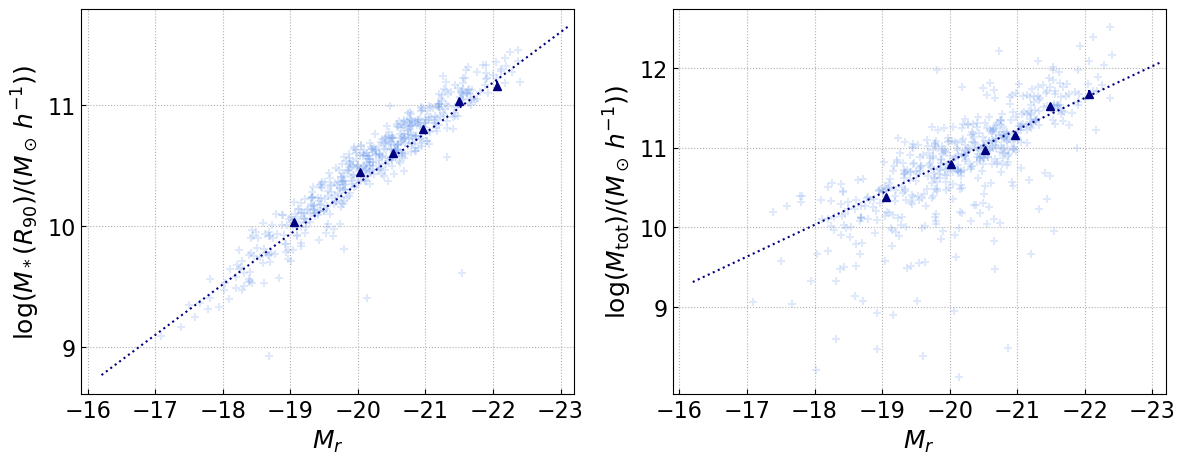

In [23]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].scatter(red_spirals['rabsmag'], red_spirals['M90_disk']+np.log10(0.73), marker='+', color='cornflowerblue', alpha=0.2)
ax[1].scatter(red_spirals['rabsmag'], red_spirals['M_R90'], marker='+', color='cornflowerblue', alpha=0.2)
ax[0].errorbar(rs_mr_ctrs, rs_mstar_avg, yerr=rs_mstar_sig, color='navy', linestyle='none', marker='^')
ax[1].errorbar(rs_mr_ctrs, rs_mtot_avg, yerr=rs_mtot_sig, color='navy', linestyle='none', marker='^')
ax[0].set_yticks(np.arange(9,13,1))
ax[1].set_yticks(np.arange(9,14,1))
ax[0].set_ylabel(r'$\log(M_*(R_{90})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[1].set_ylabel(r'$\log(M_{\rm tot})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[0].plot(mr_bins, mr_bins*gs_mstar_popt[0] + gs_mstar_popt[1], linestyle=':', color='navy')
ax[1].plot(mr_bins, mr_bins*gs_mtot_popt[0] + gs_mtot_popt[1], linestyle=':', color='navy')


for i in range(2):
    ax[i].set_xlim(-15.9,-23.2)
    ax[i].set_xlabel(r'$M_r$', fontsize=18)
    ax[i].tick_params( axis='both', direction='in', labelsize=16)
    ax[i].grid( linestyle=':')
    ax[i].set_xticks(np.arange(-23,-15,1))


fig.subplots_adjust(wspace=0.2, hspace=0.05)


#### combine all

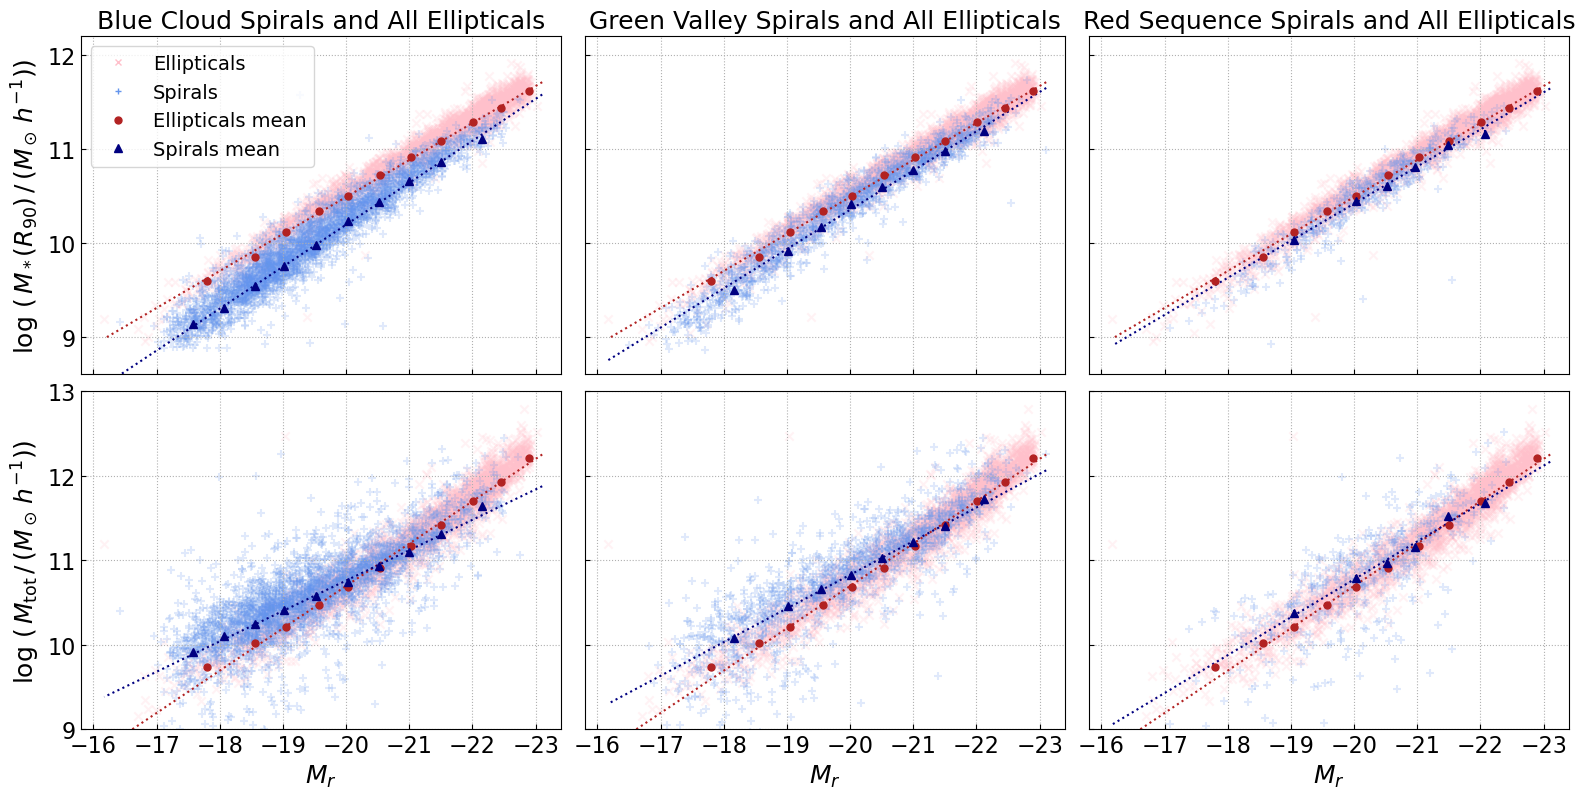

In [24]:
fig, ax = plt.subplots(2,3,sharex=True, sharey='row', figsize=(19.2,9))

# label plots
ax[0,0].set_title('Blue Cloud Spirals and All Ellipticals',fontsize=18)
ax[0,1].set_title('Green Valley Spirals and All Ellipticals',fontsize=18)
ax[0,2].set_title('Red Sequence Spirals and All Ellipticals', fontsize=18)
ax[0,0].set_ylabel(r'$\log\,(\,M_*(R_{90})\,/\,(M_\odot\,h^{-1}))$',fontsize=18)
ax[1,0].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$',fontsize=18)

ax[0,0].set_yticks(np.arange(9,13,1))
ax[1,0].set_yticks(np.arange(9,14,1))
ax[1,0].set_ylim(9,13)
ax[0,0].set_ylim(8.6, 12.2)
ax[0,0].set_yticks(np.arange(9,13,1))
ax[1,0].set_yticks(np.arange(9,14,1))
rs = np.linspace(-23.2,-17.2,100)


for i in range(0,2):
    for j in range(0,3):
        ax[i,j].tick_params( axis='both', direction='in', labelsize=16)
        ax[i,j].grid( linestyle=':')


for i in range(0,3):

    ax[1,i].set_xlabel(r'$M_r$', fontsize=18)
    
    ax[1,i].set_xticks(np.arange(-23,-15,1))
    ax[1,i].set_xlim(-15.8, -23.4)
    
    ax[0,i].scatter(ellipticals['rabsmag'], ellipticals['e_Mstar_R90']+np.log10(0.73), color='pink', marker='x', alpha=0.2)
    ax[0,i].errorbar(e_mr_ctrs, e_mstar_avg, color='firebrick', yerr=e_mstar_sig, 
                 marker='o', linestyle='none', markersize=5, )
    ax[0,i].plot(mr_bins, e_mstar_popt[0]*mr_bins + e_mstar_popt[1], color='firebrick', linestyle=':')

    
    ax[1,i].scatter(ellipticals['rabsmag'], ellipticals['Mvir'], color='pink', marker='x', alpha=0.2)
    ax[1,i].errorbar(e_mr_ctrs,e_mtot_avg, color='firebrick', yerr=e_mtot_sig, 
                 marker='o',linestyle='none', markersize=5, )
    ax[1,i].plot(mr_bins, e_mtot_popt[0]*mr_bins + e_mtot_popt[1], color='firebrick', linestyle=':')




legend_elements = [Line2D([0], [0], marker='x', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='Ellipticals mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='^', color='w', label='Spirals mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


ax[0,0].legend(handles=legend_elements,fontsize=14)



ax[0,0].scatter(blue_spirals['rabsmag'], blue_spirals['M90_disk']+np.log10(0.73), color='cornflowerblue', marker='+', alpha=0.2)
ax[0,0].errorbar(bs_mr_ctrs, bs_mstar_avg, color='navy', yerr=bs_mstar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,0].plot(mr_bins, bs_mstar_popt[0]*mr_bins + bs_mstar_popt[1], color='navy', linestyle=':')




ax[0,1].scatter(green_spirals['rabsmag'], green_spirals['M90_disk']+np.log10(0.73), color='cornflowerblue', marker='+', alpha=0.2)
ax[0,1].errorbar(gs_mr_ctrs, gs_mstar_avg, color='navy', yerr=gs_mstar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,1].plot(mr_bins, gs_mstar_popt[0]*mr_bins + gs_mstar_popt[1], color='navy', linestyle=':')





ax[0,2].scatter(red_spirals['rabsmag'], red_spirals['M90_disk']+np.log10(0.73), color='cornflowerblue', marker='+', alpha=0.2)
ax[0,2].errorbar(rs_mr_ctrs,rs_mstar_avg, color='navy', yerr=rs_mstar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,2].plot(mr_bins, rs_mstar_popt[0]*mr_bins + rs_mstar_popt[1], color='navy', linestyle=':')



ax[1,0].scatter(blue_spirals['rabsmag'], blue_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[1,0].errorbar(bs_mr_ctrs, bs_mtot_avg, color='navy', yerr=bs_mtot_sig, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[1,0].plot(mr_bins, bs_mtot_popt[0]*mr_bins + bs_mtot_popt[1], color='navy', linestyle=':')



ax[1,1].scatter(green_spirals['rabsmag'], green_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[1,1].errorbar(gs_mr_ctrs, gs_mtot_avg, color='navy', yerr=gs_mtot_sig, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[1,1].plot(mr_bins, gs_mtot_popt[0]*mr_bins + gs_mtot_popt[1], color='navy', linestyle=':')



ax[1,2].scatter(red_spirals['rabsmag'], red_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='red sequence spirals')
ax[1,2].errorbar(rs_mr_ctrs, rs_mtot_avg, color='navy', yerr=rs_mtot_sig, 
                 marker='^', label='red sequence spiral median',linestyle='none', markersize=6,)
ax[1,2].plot(mr_bins, rs_mtot_popt[0]*mr_bins + rs_mtot_popt[1], color='navy', linestyle=':')

fig.subplots_adjust(wspace=0.05, hspace=0.05)
# fig.savefig(plot_dir + 'paper_plots/Mtot_Mstar_Mr_CMDspiral_ellipticals.png', bbox_inches='tight')

### mtot vs mvis

In [15]:
HI_spirals = spirals[spirals['logHI_R90']>0]
HI_spirals['Mstar_tot'] = np.log10(8 * np.pi * HI_spirals['R_bulge']**3 * HI_spirals['rho_bulge'] + 2 * np.pi * HI_spirals['Sigma_disk'] * HI_spirals['R_disk']**2)
HI_spirals['Mstar_MHI'] = np.log10(10**(HI_spirals['logHI']+np.log10(0.7)) + 10**(HI_spirals['M90_disk']+np.log10(0.73))) # in h units
ellipticals['e_Mstar_R90_h'] = ellipticals['e_Mstar_R90'] + np.log10(0.73)

#### hi (obs) + mstar vs mtot

In [16]:
mvis_bins = np.linspace(np.min([np.min(HI_spirals['Mstar_MHI']), np.min(ellipticals['e_Mstar_R90_h'])]),
                  np.max([np.max(HI_spirals['Mstar_MHI']), np.max(ellipticals['e_Mstar_R90_h'])]), 15)

In [17]:
# ellipticals
e_mvis_ctrs = []
e_mtot = []
e_mvis_bins = np.concatenate((mvis_bins[:0], mvis_bins[3:13], mvis_bins[-1:]))

for i in range(len(e_mvis_bins)-1):
    
    mag_lim = e_mvis_bins[i+1]
    
    if i == 0:
        e_mtot.append(ellipticals['Mvir'][ellipticals['e_Mstar_R90_h'] <= mag_lim])
        e_mvis_ctrs.append(np.mean(ellipticals['e_Mstar_R90_h'][ellipticals['e_Mstar_R90_h'] <= mag_lim]+np.log10(0.73)))

    else:
        lower_lim = e_mvis_bins[i]
        e_mtot.append(ellipticals['Mvir'][np.logical_and(ellipticals['e_Mstar_R90_h'] <= mag_lim, 
                                                                         ellipticals['e_Mstar_R90_h'] > lower_lim)])
        e_mvis_ctrs.append(np.mean(ellipticals['e_Mstar_R90_h'][np.logical_and(ellipticals['e_Mstar_R90_h'] <= mag_lim, 
                                                                         ellipticals['e_Mstar_R90_h'] > lower_lim)]+np.log10(0.73)))

e_mtot_avg, e_mtot_sig = fit_to_gaussian(e_mtot, plot_dir = plot_dir, plot_name='e_Mtot_Mvis', xlab=r'$M_{\rm tot}$')

# fit da lines

e_mtot_popt, e_mtot_pcov = curve_fit(lin_fit, e_mvis_ctrs, 
                                       e_mtot_avg, sigma=e_mtot_sig)

print(e_mtot_popt, np.sqrt(e_mtot_pcov[0,0]), np.sqrt(e_mtot_pcov[1,1]))

[ 1.22311387 -1.95306955] 0.036905430059900844 0.3979062201513567


In [18]:
e_mtot_avg

array([ 9.81532066, 10.050017  , 10.27659145, 10.51805849, 10.75579453,
       11.00018738, 11.31090856, 11.60876718, 11.87348956, 12.16026209])

In [19]:
s_mvis_ctrs = []
s_mtot = []
s_mvis_bins = np.concatenate((mvis_bins[:0], mvis_bins[2:-5], mvis_bins[-1:]))
# s_mvis_bins = mvis_bins

for i in range(len(s_mvis_bins)-1):
    
    mag_lim = s_mvis_bins[i+1]
    
    if i == 0:
        s_mtot.append(HI_spirals['M_R90'][HI_spirals['Mstar_MHI'] <= mag_lim])
        s_mvis_ctrs.append(np.mean(HI_spirals['Mstar_MHI'][HI_spirals['Mstar_MHI'] <= mag_lim]+np.log10(0.73)))

    else:
        lower_lim = s_mvis_bins[i]
        s_mtot.append(HI_spirals['M_R90'][np.logical_and(HI_spirals['Mstar_MHI'] <= mag_lim, 
                                                                         HI_spirals['Mstar_MHI'] > lower_lim)])
        s_mvis_ctrs.append(np.mean(HI_spirals['Mstar_MHI'][np.logical_and(HI_spirals['Mstar_MHI'] <= mag_lim, 
                                                                         HI_spirals['Mstar_MHI'] > lower_lim)]+np.log10(0.73)))

s_mtot_avg, s_mtot_sig = fit_to_gaussian(s_mtot, plot_dir = plot_dir, plot_name='s_Mtot_MstarHIobs', xlab=r'$M_{\rm tot}$')

# fit da lines

s_mtot_popt, s_mtot_pcov = curve_fit(lin_fit, s_mvis_ctrs, 
                                       s_mtot_avg, sigma=s_mtot_sig)

print(s_mtot_popt, np.sqrt(s_mtot_pcov[0,0]), np.sqrt(s_mtot_pcov[1,1]))

[0.85465667 1.99960833] 0.025271366102242104 0.2552516261122151


In [20]:
s_mtot_avg

array([10.0058441 , 10.17879135, 10.36494031, 10.54473353, 10.69335185,
       10.9130586 , 11.07317041, 11.38990468])

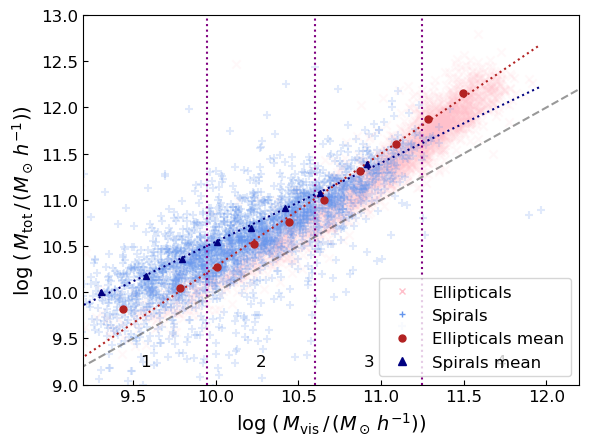

In [21]:
plt.axvline(9.95, color='purple', alpha=1, linestyle=':')
plt.axvline(10.6, color='purple', alpha=1,linestyle=':')
plt.axvline(11.25, color='purple', alpha=1,linestyle=':')

plt.scatter(ellipticals['e_Mstar_R90_h'], ellipticals['Mvir'], color='pink', alpha=0.1, marker='x')
plt.scatter(HI_spirals['Mstar_MHI'], HI_spirals['M_R90'], 
            color='cornflowerblue', alpha=0.2, marker='+')


plt.xlabel(r'$\log\,(\,M_{\rm vis}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
plt.xlim(9.2,12.2)
plt.ylim(9,13)
plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
# plt.title('Elliptical and spiral galaxy total masses')
plt.tick_params( axis='both', direction='in',labelsize=12)
plt.plot([9,13],[9,13], color='k', linestyle='--', alpha=0.4)

plt.plot(mvis_bins, mvis_bins*e_mtot_popt[0] + e_mtot_popt[1], color='firebrick', linestyle=':')
plt.plot(mvis_bins, mvis_bins*s_mtot_popt[0] + s_mtot_popt[1], color='navy', linestyle=':')


plt.errorbar(e_mvis_ctrs, e_mtot_avg, color='firebrick', yerr=e_mtot_sig, 
             marker='o',linestyle='none', markersize=5, )


plt.errorbar(s_mvis_ctrs, s_mtot_avg, color='navy', yerr=s_mtot_sig, 
             marker='^',linestyle='none', markersize=5, )


legend_elements = [Line2D([0], [0], marker='x', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='Ellipticals mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='^', color='w', label='Spirals mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


plt.legend(handles=legend_elements,fontsize=12)


plt.text((9.2+9.95)/2,9.2,'1', fontsize=12, ha='center')
plt.text((9.95+10.6)/2,9.2,'2', fontsize=12,ha='center')
plt.text((10.6 + 11.25)/2,9.2,'3', fontsize=12,ha='center')
plt.text((11.25+12.2)/2,9.2,'4', fontsize=12,ha='center')

plt.savefig(plot_dir + 'paper_plots/Mvis_Mtot_ellipticals_median.png')

### BPT

In [15]:
BPT_dict = {1.0: 'slateblue',
            2.0: 'limegreen',
            3.0:'lightcoral',
            0: 'k',}

BPT_m_dict = {1.0: 's',
              2.0: '^',
              3.0: 'o',
             0: '.'}
BPT_s_dict = {1.0: 5,
              2.0: 10,
              3.0: 10,
             0: 1}

def dust_corr(Ha, Hb, N2, O3, corr_law='CCM89'):
    
    rc= pn.RedCorr(law=corr_law)

    H_ratio = Ha/Hb

    rc.setCorr(H_ratio / 2.86, 6562, 4861)

    # in order Ha, Hb, NII, OIII
    wavelengths = np.array([6562, 4861, 6583, 5006])
    corr = rc.getCorrHb(wavelengths)

    Ha_corr = Ha * corr[0]
    Hb_corr = Hb * corr[1]
    N2_corr = N2 * corr[2]
    O3_corr = O3 * corr[3]

    return Ha_corr, Hb_corr, N2_corr, O3_corr

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_68617/4163645990.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  H_ratio = Ha/Hb
/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/pyneb/extinction/red_corr.py:252: RuntimeWarning: invalid value encountered in divide
  return np.squeeze(10. ** (0.4 * np.outer(X, self.E_BV).reshape(X.shape + self.E_BV.shape))) / rel_corr
/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/pyneb/extinction/red_corr.py:316: RuntimeWarning: divide by zero encountered in log10
  self.E_BV = 2.5 * np.log10(obs_over_theo) / (f1 - f2)
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_68617/3197918023.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(N2/Ha),
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_68617/3197918023.py:11: RuntimeWarning: divide by zero encountered in log10
  np.log10(O3/Hb),
/var/folders/4q/zk1xkb454t7_ncsh

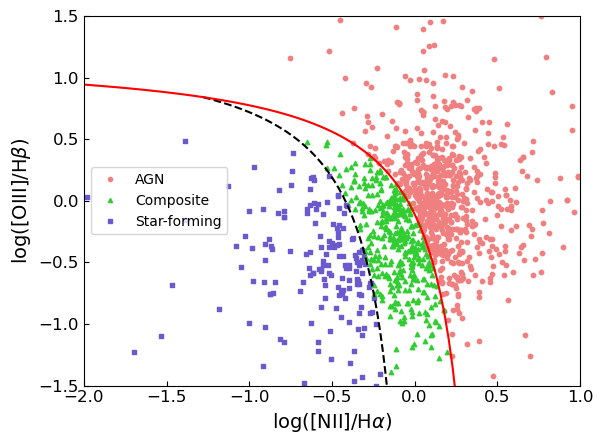

In [16]:
for i in range(len(ellipticals)):
    
    nsaid = ellipticals[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]


    Ha, Hb, N2, O3 = dust_corr(nsa_portsmouth['Flux_Ha_6562'][nsa_idx], nsa_portsmouth['Flux_Hb_4861'][nsa_idx],
                               nsa_portsmouth['Flux_NII_6583'][nsa_idx], nsa_portsmouth['Flux_OIII_5006'][nsa_idx])

    plt.scatter(np.log10(N2/Ha),
                    np.log10(O3/Hb),
                    marker=BPT_m_dict[ellipticals[i]['BPT_class']], color=BPT_dict[ellipticals[i]['BPT_class']],
                    alpha=1, s=BPT_s_dict[ellipticals[i]['BPT_class']]
               )

plt.xlim(-2,1)
plt.ylim(-1.5,1.5)

x = np.linspace(-1.28,0,100)
plt.plot(x,0.61/(x-0.05) + 1.3, color='k', linestyle='--')
x1 = np.linspace(-2,0.4,100)
plt.plot(x1,0.61/(x1 - 0.47) + 1.19, color='r')

plt.xlabel(r'log([NII]/H$\alpha$)', fontsize=14)
plt.ylabel(r'log([OIII]/H$\beta$)', fontsize=14)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='AGN',
                          markeredgecolor='lightcoral', mfc='lightcoral',markersize=3),
                   Line2D([0], [0], marker='^', color='w', label='Composite',
                          markeredgecolor='limegreen', mfc='limegreen',markersize=3),
                   Line2D([0], [0], marker='s', color='w', label='Star-forming',
                          markeredgecolor='slateblue', mfc='slateblue',markersize=3)]
plt.tick_params( axis='both', direction='in', labelsize=12)

plt.legend(handles=legend_elements)
# plt.savefig(plot_dir + 'ellipticals_BPT.png', bbox_inches='tight')

In [17]:
u_ellipticals = ellipticals[ellipticals['BPT_class']==0]
sf_ellipticals = ellipticals[ellipticals['BPT_class']==1]
c_ellipticals = ellipticals[ellipticals['BPT_class']==2]
agn_ellipticals = ellipticals[ellipticals['BPT_class']==3]

In [137]:
bins = np.linspace(9.3,11.9,5)
bins = np.array([np.min(ellipticals['sphd_M_star']) + np.log10(0.73),9.95,10.6,11.25,np.max(ellipticals['sphd_M_star']) + np.log10(0.73)])

all_mtot_mstar = []
agn_mtot_mstar = []
sf_mtot_mstar = []
c_mtot_mstar = []

all_mtot = []
agn_mtot = []
sf_mtot = []
c_mtot = []

all_ctr = []
agn_ctr = []
sf_ctr = []
c_ctr = []

sf_bins = np.concatenate((bins[:1], bins[2:]))
c_bins = sf_bins



ellipticals_mtot_mstar = 10**(ellipticals['Mvir'] - (ellipticals['sphd_M_star']+np.log10(0.73)))
agn_ellipticals_mtot_mstar = 10**(agn_ellipticals['Mvir'] - (agn_ellipticals['sphd_M_star']+np.log10(0.73)))
c_ellipticals_mtot_mstar = 10**(c_ellipticals['Mvir'] - (c_ellipticals['sphd_M_star']+np.log10(0.73)))
sf_ellipticals_mtot_mstar = 10**(sf_ellipticals['Mvir'] - (sf_ellipticals['sphd_M_star']+np.log10(0.73)))



for i in range(len(bins)-1):
    mag_lim = bins[i+1]
    if i == 0:
        all_mtot_mstar.append(ellipticals_mtot_mstar[ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim] )
        agn_mtot_mstar.append(agn_ellipticals_mtot_mstar[agn_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim])
    
        all_mtot.append(ellipticals['Mvir'][ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim])
        agn_mtot.append(agn_ellipticals['Mvir'][agn_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim])
     
        all_ctr.append(np.mean(ellipticals['sphd_M_star'][ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim]+np.log10(0.73)))
        agn_ctr.append(np.mean(agn_ellipticals['sphd_M_star'][agn_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim]+np.log10(0.73)))
        
    else:
        lower_lim = bins[i]
        all_mtot_mstar.append(ellipticals_mtot_mstar[np.logical_and(ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])
        agn_mtot_mstar.append(agn_ellipticals_mtot_mstar[np.logical_and(agn_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         agn_ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])
        
        all_mtot.append(ellipticals['Mvir'][np.logical_and(ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])
        agn_mtot.append(agn_ellipticals['Mvir'][np.logical_and(agn_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         agn_ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])
        

        all_ctr.append(np.mean(ellipticals['sphd_M_star'][np.logical_and(ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)]+np.log10(0.73)))
        agn_ctr.append(np.mean(agn_ellipticals['sphd_M_star'][np.logical_and(agn_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         agn_ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)]+np.log10(0.73)))
       

for i in range(len(sf_bins)-1):
    mag_lim = sf_bins[i+1]
    if i == 0:
        sf_mtot_mstar.append(sf_ellipticals_mtot_mstar[sf_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim])
        c_mtot_mstar.append(c_ellipticals_mtot_mstar[c_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim])

        sf_mtot.append(sf_ellipticals['Mvir'][sf_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim])
        c_mtot.append(c_ellipticals['Mvir'][c_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim])

        sf_ctr.append(np.mean(sf_ellipticals['sphd_M_star'][sf_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim]+np.log10(0.73)))
        c_ctr.append(np.mean(c_ellipticals['sphd_M_star'][c_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim]+np.log10(0.73)))

        
    else:
        lower_lim = sf_bins[i]
        sf_mtot_mstar.append(sf_ellipticals_mtot_mstar[np.logical_and(sf_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         sf_ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])
        c_mtot_mstar.append(c_ellipticals_mtot_mstar[np.logical_and(c_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         c_ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])

        sf_mtot.append(sf_ellipticals['Mvir'][np.logical_and(sf_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         sf_ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])
        c_mtot.append(c_ellipticals['Mvir'][np.logical_and(c_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         c_ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])


        sf_ctr.append(np.mean(sf_ellipticals['sphd_M_star'][np.logical_and(sf_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         sf_ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)]+np.log10(0.73)))
        c_ctr.append(np.mean(c_ellipticals['sphd_M_star'][np.logical_and(c_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         c_ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)]+np.log10(0.73)))

    

all_mtot_mstar_avg, all_mtot_mstar_sig = fit_to_gaussian(all_mtot_mstar, plot_dir = plot_dir, 
                                                         plot_name='ellipticals_Mtot_Mstar', xlab=r'$M_{\rm tot}$',
                                                        use_custom_bins=True, custom_bins=[np.concatenate((np.linspace(0,20,20),np.array([100]))),
                                                                                           np.concatenate((np.linspace(0,20,20),np.array([100]))),
                                                                                           33,
                                                                                           33])
agn_mtot_mstar_avg, agn_mtot_mstar_sig = fit_to_gaussian(agn_mtot_mstar, plot_dir = plot_dir, 
                                                         plot_name='agn_Mtot_Mstar', xlab=r'$M_{\rm tot}$')
sf_mtot_mstar_avg, sf_mtot_mstar_sig = fit_to_gaussian(sf_mtot_mstar, plot_dir = plot_dir, 
                                                         plot_name='sf_Mtot_Mstar', xlab=r'$M_{\rm tot}$',
                                                      use_custom_bins=True, 
                                                      custom_bins=[np.linspace(0,4,6)
                                                                   ,8,8
                                                      ])
c_mtot_mstar_avg, c_mtot_mstar_sig = fit_to_gaussian(c_mtot_mstar, plot_dir = plot_dir, 
                                                         plot_name='c_Mtot_Mstar', xlab=r'$M_{\rm tot}$')


all_mtot_avg, all_mtot_sig = fit_to_gaussian(all_mtot, plot_dir = plot_dir, 
                                                         plot_name='all_ellipticals_Mtot', xlab=r'$M_{\rm tot}$')
agn_mtot_avg, agn_mtot_sig = fit_to_gaussian(agn_mtot, plot_dir = plot_dir, 
                                                         plot_name='agn_Mtot', xlab=r'$M_{\rm tot}$')
sf_mtot_avg, sf_mtot_sig = fit_to_gaussian(sf_mtot, plot_dir = plot_dir, 
                                                         plot_name='sf_Mtot', xlab=r'$M_{\rm tot}$')
c_mtot_avg, c_mtot_sig = fit_to_gaussian(c_mtot, plot_dir = plot_dir, 
                                                         plot_name='c_Mtot', xlab=r'$M_{\rm tot}$')

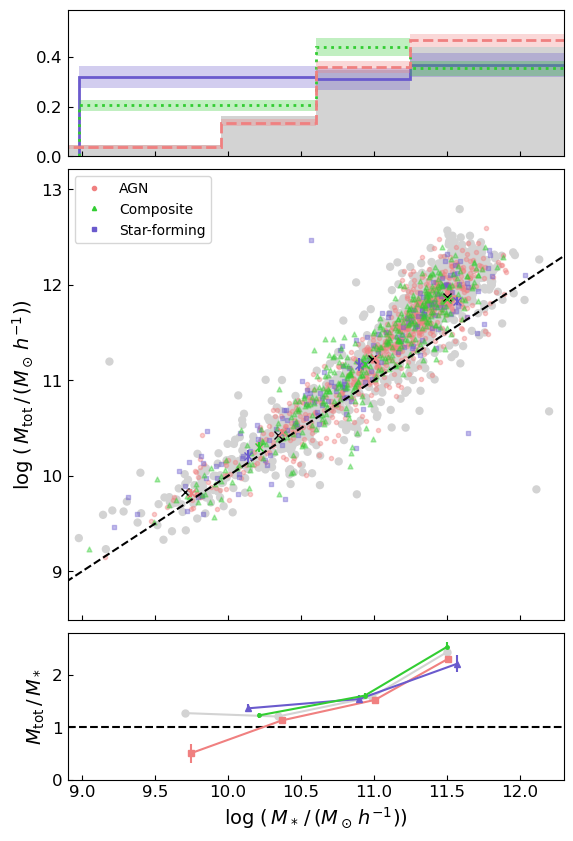

In [138]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))
ax[0].stairs([len(all_mtot[0])/len(ellipticals),len(all_mtot[1])/len(ellipticals),
              len(all_mtot[2])/len(ellipticals), len(all_mtot[3])/len(ellipticals)], [8.7,9.95,10.6,11.25,13], 
             color='lightgrey', fill=True, alpha=1, label=r'all ellipticals')

         
ax[0].stairs([len(sf_mtot[0])/len(sf_ellipticals),len(sf_mtot[1])/len(sf_ellipticals),
              len(sf_mtot[2])/len(sf_ellipticals)], sf_bins,
             color='slateblue', alpha=1, label=r'sf', lw=2)

ax[0].stairs([(len(sf_mtot[0])+np.sqrt(len(sf_mtot[0])))/len(sf_ellipticals),
              (len(sf_mtot[1])+np.sqrt(len(sf_mtot[1])))/len(sf_ellipticals),
              (len(sf_mtot[2])+np.sqrt(len(sf_mtot[2])))/len(sf_ellipticals)], 
                sf_bins,
                baseline=[(len(sf_mtot[0])-np.sqrt(len(sf_mtot[0])))/len(sf_ellipticals),
              (len(sf_mtot[1])-np.sqrt(len(sf_mtot[1])))/len(sf_ellipticals),
              (len(sf_mtot[2])-np.sqrt(len(sf_mtot[2])))/len(sf_ellipticals)],
             color='slateblue', alpha=0.3, label=r'sf', lw=2, fill=True)

ax[0].stairs([len(c_mtot[0])/len(c_ellipticals),
              len(c_mtot[1])/len(c_ellipticals),
              len(c_mtot[2])/len(c_ellipticals)], 
              sf_bins,
             color='limegreen', alpha=1, label=r'sf', linestyle=':',lw=2)

ax[0].stairs([(len(c_mtot[0])+np.sqrt(len(c_mtot[0])))/len(c_ellipticals),
              (len(c_mtot[1])+np.sqrt(len(c_mtot[1])))/len(c_ellipticals),
              (len(c_mtot[2])+np.sqrt(len(c_mtot[2])))/len(c_ellipticals)],
             sf_bins,
             baseline=[
                 (len(c_mtot[0])-np.sqrt(len(c_mtot[0])))/len(c_ellipticals),
                 (len(c_mtot[1])-np.sqrt(len(c_mtot[1])))/len(c_ellipticals),
                 (len(c_mtot[2])-np.sqrt(len(c_mtot[2])))/len(c_ellipticals)],
             color='limegreen', alpha=0.3, label=r'sf', lw=2, fill=True)


ax[0].stairs([len(agn_mtot[0])/len(agn_ellipticals),
              len(agn_mtot[1])/len(agn_ellipticals),
              len(agn_mtot[2])/len(agn_ellipticals), 
              len(agn_mtot[3])/len(agn_ellipticals)], [8.7,9.95,10.6,11.25,13],
             color='lightcoral', alpha=1, label=r'sf', linestyle='--', lw=2)


ax[0].stairs([(len(agn_mtot[0])+np.sqrt(len(agn_mtot[0])))/len(agn_ellipticals),
              (len(agn_mtot[1])+np.sqrt(len(agn_mtot[1])))/len(agn_ellipticals),
              (len(agn_mtot[2])+np.sqrt(len(agn_mtot[2])))/len(agn_ellipticals),
              (len(agn_mtot[3])+np.sqrt(len(agn_mtot[3])))/len(agn_ellipticals)], 
                [8.7,9.95,10.6,11.25,13],
                baseline=[(len(agn_mtot[0])-np.sqrt(len(agn_mtot[0])))/len(agn_ellipticals),
              (len(agn_mtot[1])-np.sqrt(len(agn_mtot[1])))/len(agn_ellipticals),
              (len(agn_mtot[2])-np.sqrt(len(agn_mtot[2])))/len(agn_ellipticals),
              (len(agn_mtot[3])-np.sqrt(len(agn_mtot[3])))/len(agn_ellipticals)],
             color='lightcoral', alpha=0.3, label=r'sf', lw=2, fill=True)




ax[1].scatter(u_ellipticals['sphd_M_star']+np.log10(0.73), u_ellipticals['Mvir'], color='lightgrey',edgecolor='none', alpha=1)
ax[1].scatter(agn_ellipticals['sphd_M_star']+np.log10(0.73), agn_ellipticals['Mvir'], color='lightcoral', marker='.', alpha=0.4)
ax[1].scatter(sf_ellipticals['sphd_M_star']+np.log10(0.73), sf_ellipticals['Mvir'], color='slateblue', marker='s', alpha=0.4, s=8)
ax[1].scatter(c_ellipticals['sphd_M_star']+np.log10(0.73), c_ellipticals['Mvir'], color='limegreen', marker='^', alpha=0.4, s=12)


ax[1].errorbar(all_ctr, all_mtot_avg, yerr=all_mtot_sig, marker='x', color='k', linestyle='none')
ax[1].errorbar(agn_ctr, agn_mtot_avg, yerr=agn_mtot_sig, marker='x', color='lightcoral', linestyle='none')
ax[1].errorbar(sf_ctr, sf_mtot_avg, yerr=sf_mtot_sig, marker='x', color='slateblue', linestyle='none')
ax[1].errorbar(c_ctr, c_mtot_avg, yerr=c_mtot_sig, marker='x', color='limegreen', linestyle='none')

ax[1].set_xlim(8.9,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

legend_elements = [Line2D([0], [0], marker='o', color='w', label='AGN',
                          markeredgecolor='lightcoral', mfc='lightcoral',markersize=3),
                   Line2D([0], [0], marker='^', color='w', label='Composite',
                          markeredgecolor='limegreen', mfc='limegreen',markersize=3),
                   Line2D([0], [0], marker='s', color='w', label='Star-forming',
                          markeredgecolor='slateblue', mfc='slateblue', markersize=3)]

ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.59)



ax[2].errorbar(all_ctr, all_mtot_mstar_avg, color='lightgrey', yerr=all_mtot_mstar_sig, 
             marker='o', markersize=5, )

ax[2].errorbar(agn_ctr, agn_mtot_mstar_avg, color='lightcoral', yerr=agn_mtot_mstar_sig, 
             marker='s', markersize=5, )
ax[2].errorbar(sf_ctr, sf_mtot_mstar_avg, color='slateblue', yerr=sf_mtot_mstar_sig, 
             marker='^', markersize=5, )
ax[2].errorbar(c_ctr, c_mtot_mstar_avg, color='limegreen', yerr=c_mtot_mstar_sig, 
             marker='.', markersize=5, )


ax[2].axhline(1 , color='k', linestyle='--')

ax[2].set_ylim(0,2.8)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)
plt.savefig(plot_dir + 'paper_plots/Mtot_Mstar_BPT_hist.png', bbox_inches='tight')

### metallicity

In [130]:
print(np.min(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99]))
print(np.max(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99]))

-0.528823407655138
0.187093875308831


In [139]:
counts, bins = np.histogram(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99])

In [140]:
bin_ctrs = (bins[:-1] + bins[1:])/2
popt, pcov = curve_fit(gaussian, bin_ctrs, counts)

In [141]:
z_bins

array([-0.52882341, -0.13076085,  0.0621018 ,  0.18709388])

In [145]:
z_bins = np.linspace(np.min(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99]),
                     np.max(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99]),4)
z_bins = np.array([np.min(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99]),
                   popt[1]-popt[2], popt[1]+popt[2],
                     np.max(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99])])
bins = np.array([np.min(ellipticals['sphd_M_star']) + np.log10(0.73),9.95,10.6,11.25,np.max(ellipticals['sphd_M_star']) + np.log10(0.73)])


low_z = ellipticals[np.logical_and(ellipticals['ZH_LW_Re_fit'] > -99, ellipticals['ZH_LW_Re_fit'] <= z_bins[1])]
mid_z = ellipticals[np.logical_and(ellipticals['ZH_LW_Re_fit'] > z_bins[1], ellipticals['ZH_LW_Re_fit'] <= z_bins[2])]
high_z = ellipticals[ellipticals['ZH_LW_Re_fit'] > z_bins[2]]

low_z_ellipticals_mtot_mstar = 10**(low_z['Mvir'] - (low_z['sphd_M_star']+np.log10(0.73)))
mid_z_ellipticals_mtot_mstar = 10**(mid_z['Mvir'] - (mid_z['sphd_M_star']+np.log10(0.73)))
high_z_ellipticals_mtot_mstar = 10**(high_z['Mvir'] - (high_z['sphd_M_star']+np.log10(0.73)))

low_z_mtot_mstar = []
mid_z_mtot_mstar = []
high_z_mtot_mstar = []

low_z_mtot = []
mid_z_mtot = []
high_z_mtot = []

low_z_ctr = []
mid_z_ctr = []
high_z_ctr = []

high_z_bins = np.concatenate((bins[:1], bins[2:]))

for i in range(4):
    mag_lim = bins[i+1]
    if i == 0:
        low_z_mtot_mstar.append(low_z_ellipticals_mtot_mstar[low_z['sphd_M_star']+np.log10(0.73) <= mag_lim])
        mid_z_mtot_mstar.append(mid_z_ellipticals_mtot_mstar[mid_z['sphd_M_star']+np.log10(0.73) <= mag_lim])

        low_z_mtot.append(low_z['Mvir'][low_z['sphd_M_star']+np.log10(0.73) <= mag_lim])
        mid_z_mtot.append(mid_z['Mvir'][mid_z['sphd_M_star']+np.log10(0.73) <= mag_lim])

        low_z_ctr.append(np.mean(low_z['sphd_M_star'][low_z['sphd_M_star']+np.log10(0.73) <= mag_lim]+np.log10(0.73)))
        mid_z_ctr.append(np.mean(mid_z['sphd_M_star'][mid_z['sphd_M_star']+np.log10(0.73) <= mag_lim]+np.log10(0.73)))

        
    else:
        lower_lim = bins[i]
        low_z_mtot_mstar.append(low_z_ellipticals_mtot_mstar[np.logical_and(low_z['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         low_z['sphd_M_star']+np.log10(0.73) > lower_lim)])
        mid_z_mtot_mstar.append(mid_z_ellipticals_mtot_mstar[np.logical_and(mid_z['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         mid_z['sphd_M_star']+np.log10(0.73) > lower_lim)])

        low_z_mtot.append(low_z['Mvir'][np.logical_and(low_z['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         low_z['sphd_M_star']+np.log10(0.73) > lower_lim)])
        mid_z_mtot.append(mid_z['Mvir'][np.logical_and(mid_z['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         mid_z['sphd_M_star']+np.log10(0.73) > lower_lim)])
        
        low_z_ctr.append(np.mean(low_z['sphd_M_star'][np.logical_and(low_z['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         low_z['sphd_M_star']+np.log10(0.73) > lower_lim)]+np.log10(0.73)))
        mid_z_ctr.append(np.mean(mid_z['sphd_M_star'][np.logical_and(mid_z['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         mid_z['sphd_M_star']+np.log10(0.73) > lower_lim)]+np.log10(0.73)))
        

for i in range(len(high_z_bins)-1):
    mag_lim = high_z_bins[i+1]
    if i == 0:
        high_z_mtot_mstar.append(high_z_ellipticals_mtot_mstar[high_z['sphd_M_star']+np.log10(0.73) <= mag_lim])

        high_z_mtot.append(high_z['Mvir'][high_z['sphd_M_star']+np.log10(0.73) <= mag_lim])

        high_z_ctr.append(np.mean(high_z['sphd_M_star'][high_z['sphd_M_star']+np.log10(0.73) <= mag_lim]+np.log10(0.73)))

        
    else:
        lower_lim = high_z_bins[i]
        high_z_mtot_mstar.append(high_z_ellipticals_mtot_mstar[np.logical_and(high_z['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         high_z['sphd_M_star']+np.log10(0.73) > lower_lim)])

        high_z_mtot.append(high_z['Mvir'][np.logical_and(high_z['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         high_z['sphd_M_star']+np.log10(0.73) > lower_lim)])


        high_z_ctr.append(np.mean(high_z['sphd_M_star'][np.logical_and(high_z['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         high_z['sphd_M_star']+np.log10(0.73) > lower_lim)]+np.log10(0.73)))



low_z_mtot_mstar[0] = low_z_mtot_mstar[0][low_z_mtot_mstar[0] < 50]
low_z_mtot_mstar[1] = low_z_mtot_mstar[1][low_z_mtot_mstar[1] < 50]

low_z_mtot_mstar_avg, low_z_mtot_mstar_sig = fit_to_gaussian(low_z_mtot_mstar, plot_dir = plot_dir, 
                                                         plot_name='low_z_Mtot_Mstar', xlab=r'$M_{\rm tot}/M_*$')
mid_z_mtot_mstar_avg, mid_z_mtot_mstar_sig = fit_to_gaussian(mid_z_mtot_mstar, plot_dir = plot_dir, 
                                                         plot_name='mid_z_Mtot_Mstar', xlab=r'$M_{\rm tot}/M_*$',
                                                            use_custom_bins=True,
                                                            custom_bins=[np.concatenate((np.linspace(0,3,6),np.array([4]))),
                                                                         int(np.sqrt(len(mid_z_mtot_mstar[1])))+1,
                                                                         int(np.sqrt(len(mid_z_mtot_mstar[2])))+1,
                                                                        int(np.sqrt(len(mid_z_mtot_mstar[3])))+1])
                                                             
high_z_mtot_mstar_avg, high_z_mtot_mstar_sig = fit_to_gaussian(high_z_mtot_mstar, plot_dir = plot_dir, 
                                                         plot_name='high_z_Mtot_Mstar', xlab=r'$M_{\rm tot}/M_*$')


low_z_mtot_avg, low_z_mtot_sig = fit_to_gaussian(low_z_mtot, plot_dir = plot_dir, 
                                                         plot_name='low_z_Mtot', xlab=r'$M_{\rm tot}$')
mid_z_mtot_avg, mid_z_mtot_sig = fit_to_gaussian(mid_z_mtot, plot_dir = plot_dir, 
                                                         plot_name='mid_z_Mtot', xlab=r'$M_{\rm tot}$')
high_z_mtot_avg, high_z_mtot_sig = fit_to_gaussian(high_z_mtot, plot_dir = plot_dir, 
                                                         plot_name='high_z_Mtot', xlab=r'$M_{\rm tot}$')

failed on bin 0


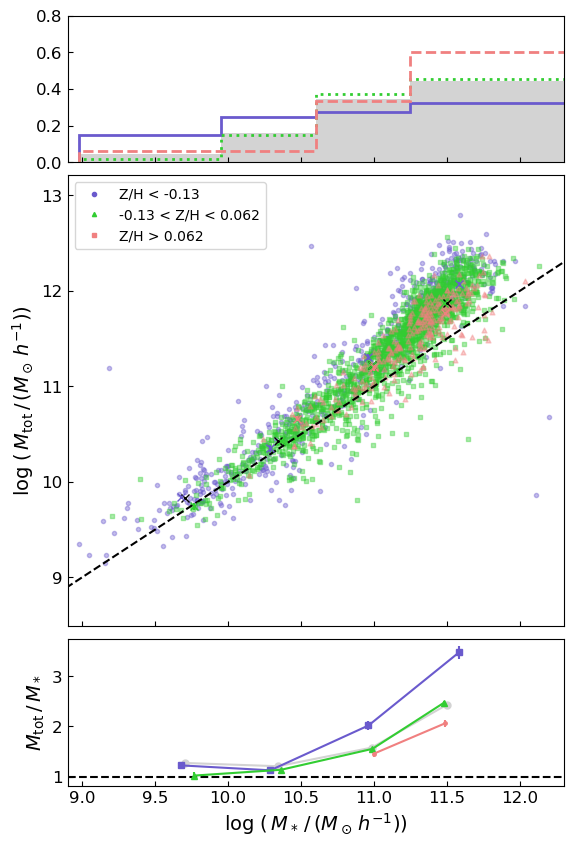

In [147]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))
ax[0].stairs([len(all_mtot[0])/len(ellipticals),len(all_mtot[1])/len(ellipticals),
              len(all_mtot[2])/len(ellipticals), len(all_mtot[3])/len(ellipticals)], bins, 
             color='lightgrey', fill=True, alpha=1, label=r'all ellipticals')

         
ax[0].stairs([len(low_z_mtot[0])/len(low_z),len(low_z_mtot[1])/len(low_z),
              len(low_z_mtot[2])/len(low_z), len(low_z_mtot[3])/len(low_z)], bins,
             color='slateblue', alpha=1, label=r'low Z', lw=2)

# ax[0].stairs([(len(bin1[bin1['BPT_class']==1])+np.sqrt(len(bin1[bin1['BPT_class']==1])))/len(sf_ellipticals),
#               (len(bin2[bin2['BPT_class']==1])+np.sqrt(len(bin2[bin2['BPT_class']==1])))/len(sf_ellipticals),
#               (len(bin3[bin3['BPT_class']==1])+np.sqrt(len(bin3[bin3['BPT_class']==1])))/len(sf_ellipticals),
#                (len(bin4[bin4['BPT_class']==1])+np.sqrt(len(bin4[bin4['BPT_class']==1])))/len(sf_ellipticals)], 
#                 [8.7,9.95,10.6,11.25,13],
#                 baseline=[(len(bin1[bin1['BPT_class']==1])-np.sqrt(len(bin1[bin1['BPT_class']==1])))/len(sf_ellipticals),
#               (len(bin2[bin2['BPT_class']==1])-np.sqrt(len(bin2[bin2['BPT_class']==1])))/len(sf_ellipticals),
#               (len(bin3[bin3['BPT_class']==1])-np.sqrt(len(bin3[bin3['BPT_class']==1])))/len(sf_ellipticals),
#                (len(bin4[bin4['BPT_class']==1])-np.sqrt(len(bin4[bin4['BPT_class']==1])))/len(sf_ellipticals)],
#              color='slateblue', alpha=0.3, label=r'sf', lw=2, fill=True)

ax[0].stairs([len(mid_z_mtot[0])/len(mid_z),len(mid_z_mtot[1])/len(mid_z),
              len(mid_z_mtot[2])/len(mid_z), len(mid_z_mtot[3])/len(mid_z)], bins,
             color='limegreen', alpha=1, label=r'mid Z', linestyle=':',lw=2)

# ax[0].stairs([(len(bin1[bin1['BPT_class']==2])+np.sqrt(len(bin1[bin1['BPT_class']==2])))/len(c_ellipticals),
#               (len(bin2[bin2['BPT_class']==2])+np.sqrt(len(bin2[bin2['BPT_class']==2])))/len(c_ellipticals),
#               (len(bin3[bin3['BPT_class']==2])+np.sqrt(len(bin3[bin3['BPT_class']==2])))/len(c_ellipticals),
#                (len(bin4[bin4['BPT_class']==2])+np.sqrt(len(bin4[bin4['BPT_class']==2])))/len(c_ellipticals)], 
#                 [8.7,9.95,10.6,11.25,13],
#                 baseline=[(len(bin1[bin1['BPT_class']==2])-np.sqrt(len(bin1[bin1['BPT_class']==2])))/len(c_ellipticals),
#               (len(bin2[bin2['BPT_class']==2])-np.sqrt(len(bin2[bin2['BPT_class']==2])))/len(c_ellipticals),
#               (len(bin3[bin3['BPT_class']==2])-np.sqrt(len(bin3[bin3['BPT_class']==2])))/len(c_ellipticals),
#                (len(bin4[bin4['BPT_class']==2])-np.sqrt(len(bin4[bin4['BPT_class']==2])))/len(c_ellipticals)],
#              color='limegreen', alpha=0.3, label=r'sf', lw=2, fill=True)


ax[0].stairs([len(high_z_mtot[0])/len(high_z),len(high_z_mtot[1])/len(high_z),
              len(high_z_mtot[2])/len(high_z)], high_z_bins,
             color='lightcoral', alpha=1, label=r'high Z', linestyle='--', lw=2)


# ax[0].stairs([(len(bin1[bin1['BPT_class']==3])+np.sqrt(len(bin1[bin1['BPT_class']==3])))/len(agn_ellipticals),
#               (len(bin2[bin2['BPT_class']==3])+np.sqrt(len(bin2[bin2['BPT_class']==3])))/len(agn_ellipticals),
#               (len(bin3[bin3['BPT_class']==3])+np.sqrt(len(bin3[bin3['BPT_class']==3])))/len(agn_ellipticals),
#                (len(bin4[bin4['BPT_class']==3])+np.sqrt(len(bin4[bin4['BPT_class']==3])))/len(agn_ellipticals)], 
#                 [8.7,9.95,10.6,11.25,13],
#                 baseline=[(len(bin1[bin1['BPT_class']==3])-np.sqrt(len(bin1[bin1['BPT_class']==3])))/len(agn_ellipticals),
#               (len(bin2[bin2['BPT_class']==3])-np.sqrt(len(bin2[bin2['BPT_class']==3])))/len(agn_ellipticals),
#               (len(bin3[bin3['BPT_class']==3])-np.sqrt(len(bin3[bin3['BPT_class']==3])))/len(agn_ellipticals),
#                (len(bin4[bin4['BPT_class']==3])-np.sqrt(len(bin4[bin4['BPT_class']==3])))/len(agn_ellipticals)],
#              color='lightcoral', alpha=0.3, label=r'sf', lw=2, fill=True)




# ax[1].scatter(ellipticals['sphd_M_star']+np.log10(0.73), ellipticals['Mvir'], color='lightgrey',edgecolor='none', alpha=1)
ax[1].scatter(low_z['sphd_M_star']+np.log10(0.73), low_z['Mvir'], color='slateblue', marker='.', alpha=0.4)
ax[1].scatter(mid_z['sphd_M_star']+np.log10(0.73), mid_z['Mvir'], color='limegreen', marker='s', alpha=0.4, s=8)
ax[1].scatter(high_z['sphd_M_star']+np.log10(0.73), high_z['Mvir'], color='lightcoral', marker='^', alpha=0.4, s=12)


ax[1].errorbar(all_ctr, all_mtot_avg, yerr=all_mtot_sig, marker='x', color='k', linestyle='none')
ax[1].errorbar(low_z_ctr, low_z_mtot_avg, yerr=low_z_mtot_sig, marker='x', color='slateblue', linestyle='none')
ax[1].errorbar(mid_z_ctr, mid_z_mtot_avg, yerr=mid_z_mtot_sig, marker='x', color='limegreen', linestyle='none')
ax[1].errorbar(high_z_ctr, high_z_mtot_avg, yerr=high_z_mtot_sig, marker='x', color='lightcoral', linestyle='none')

ax[1].set_xlim(8.9,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Z/H < {z_bins[1]:.2}',
                          markeredgecolor='slateblue', mfc='slateblue',markersize=3),
                   Line2D([0], [0], marker='^', color='w', label=f'{z_bins[1]:.2} < Z/H < {z_bins[2]:.2}',
                          markeredgecolor='limegreen', mfc='limegreen',markersize=3),
                   Line2D([0], [0], marker='s', color='w', label=f'Z/H > {z_bins[2]:.2}',
                          markeredgecolor='lightcoral', mfc='lightcoral', markersize=3)]

ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.8)



ax[2].errorbar(all_ctr, all_mtot_mstar_avg, color='lightgrey', yerr=all_mtot_mstar_sig, 
             marker='o', markersize=5, )

ax[2].errorbar(low_z_ctr, low_z_mtot_mstar_avg, color='slateblue', yerr=low_z_mtot_mstar_sig, 
             marker='s', markersize=5, )
ax[2].errorbar(mid_z_ctr, mid_z_mtot_mstar_avg, color='limegreen', yerr=mid_z_mtot_mstar_sig, 
             marker='^', markersize=5, )
ax[2].errorbar(high_z_ctr, high_z_mtot_mstar_avg, color='lightcoral', yerr=high_z_mtot_mstar_sig, 
             marker='.', markersize=5, )


ax[2].axhline(1 , color='k', linestyle='--')

# ax[2].set_ylim(0,2.8)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)
plt.savefig(plot_dir + 'paper_plots/Mtot_Mstar_ZH_hist.png', bbox_inches='tight')

In [154]:
low_z_mtot_mstar_sig

array([nan, 0.1, 0.1, 0.1])

In [155]:
low_z_mtot_mstar_avg

array([       nan, 0.96680626, 1.62994013, 5.73314022])

In [157]:
low_z[low_z_ellipticals_mtot_mstar > 50]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,Mvir2,Mvir2_err,star_sigma2,star_sigma2_err,e_Mstar_R90,BPT_class,sum_M_star_0p1_R90,count_M_star_0p1_R90,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64